# Social Network Analysis

In [79]:
import numpy as np
import pandas as pd
from bertopic import BERTopic
from transformers import AutoTokenizer
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction import text
from sklearn.metrics.pairwise import cosine_similarity
import sys
import os
sys.path.append(os.path.abspath(".."))
# Bayesian Optimizer
import optuna
from optuna.samplers import TPESampler
import seaborn as sns
import matplotlib.pyplot as plt

In [19]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No CUDA GPU")

True
NVIDIA GeForce RTX 5060 Laptop GPU


# Generate embeddings
The study utilized all-MiniLM-L12-v2 from SentenceTransformers as a lightweight and versatile language model for generating embeddings. However, the model can process fewer than 512 tokens per input. Therefore, I created a custom function (`split_text`) to divide each text into appropriate paragraphs and return the mean embedding across all paragraphs.

see: https://sbert.net/

"For transformer models like BERT, RoBERTa, DistilBERT etc., the runtime and memory requirement grows quadratic with the input length. This limits transformers to inputs of certain lengths. A common value for BERT-based models are 512 tokens, which corresponds to about 300-400 words (for English)."

After this preparation, the study further cleaned the data by removing duplicate windows before training, as duplicates can strongly affect model performance. This process is intuitive: two states may share the same window when they appear in the same sentence, but a human reads that sentence only once. The same logic applies to the model. Topic signals repeated due to co-occurrences should return to their original frequency to restore their weight in the overall corpus.

The study also identified a challenge in processing large-scale data. Batching is necessary to reduce memory usage; otherwise, the model may process all data at once, which often leads to memory overflow.

In [21]:
windows = pd.read_csv("../data/layer2/layer2_window.csv")
docs = windows['window_content'].astype(str).tolist()
# Remove duplicate windows while preserving original order
docs = list(dict.fromkeys(docs))
print(f"Docs after dedup: {len(docs):,}")

Docs after dedup: 125,717


In [22]:
tokenizer = AutoTokenizer.from_pretrained('F:/Python/Projects/Project2025/GroupA/models/all-MiniLM-L12-v2')
embedding_model = SentenceTransformer('F:/Python/Projects/Project2025/GroupA/models/all-MiniLM-L12-v2')
max_token = 512

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 5440.72it/s]
BertModel LOAD REPORT from: F:/Python/Projects/Project2025/GroupA/models/all-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [24]:
def text_embedding(text, tokenizer,embedding_model,max_tokens):
    
    # decoded text can still be over 512 tokens, so its necessary to double check
    def split_text(text, tokenizer,max_tokens):
        tokens = tokenizer.encode(text,add_special_tokens=False) # only based on the original text
        chunks = [tokens[i:i+max_tokens] for i in range(0, len(tokens),max_tokens)] # if tokens are less than 512, it automatically ends at the last meaningful token.
        texts = []
        for chunk in chunks:
            chunk_text = tokenizer.decode(chunk)
            chunk_tokens = tokenizer.encode(chunk_text,add_special_tokens=False)
            if len(chunk_tokens) <= max_tokens:
                texts.append(chunk_text)
            else:
                sub_chunks = [chunk_tokens[i:i+max_tokens] for i in range(0, len(chunk_tokens),max_tokens)]
                for sub_chunk in sub_chunks:
                    texts.append(tokenizer.decode(sub_chunk))
        return texts
    
    chunks = split_text(text, tokenizer,max_tokens)
    embs = embedding_model.encode(chunks, show_progress_bar = False)  # too many outputs
    return np.mean(embs,axis=0)

In [25]:
batch_size = 1000
output_path = '../data/layer2/embeddings/emb.npy'
temp_embeddings = []

print(f"Total Data Size: {len(docs)} ")
print(f"Batch Size: {batch_size} items")
print(f"Epochs: {(len(docs) + batch_size - 1) // batch_size}")

for batch_idx in range(0, len(docs), batch_size):
    batch_end = min(batch_idx + batch_size, len(docs))
    batch_docs = docs[batch_idx:batch_end]
    
    print(f"\n Processing {batch_idx // batch_size + 1}/({batch_idx + 1}-{batch_end}/{len(docs)})")
    
    batch_embeddings = [text_embedding(doc, tokenizer, embedding_model, max_token) for doc in batch_docs]
    temp_embeddings.extend(batch_embeddings)
    
    if (batch_idx // batch_size + 1) % 5 == 0:
        print(f"  Processed {len(temp_embeddings)} items")

embeddings = np.array(temp_embeddings)
print(f"\n Processed: {embeddings.shape}")
np.save(output_path, embeddings)
print(f"Saved into: {output_path}")

Total Data Size: 125717 
Batch Size: 1000 items
Epochs: 126

 Processing 1/(1-1000/125717)

 Processing 2/(1001-2000/125717)

 Processing 3/(2001-3000/125717)

 Processing 4/(3001-4000/125717)

 Processing 5/(4001-5000/125717)
  Processed 5000 items

 Processing 6/(5001-6000/125717)

 Processing 7/(6001-7000/125717)

 Processing 8/(7001-8000/125717)

 Processing 9/(8001-9000/125717)

 Processing 10/(9001-10000/125717)
  Processed 10000 items

 Processing 11/(10001-11000/125717)

 Processing 12/(11001-12000/125717)

 Processing 13/(12001-13000/125717)

 Processing 14/(13001-14000/125717)

 Processing 15/(14001-15000/125717)
  Processed 15000 items

 Processing 16/(15001-16000/125717)

 Processing 17/(16001-17000/125717)

 Processing 18/(17001-18000/125717)

 Processing 19/(18001-19000/125717)

 Processing 20/(19001-20000/125717)
  Processed 20000 items

 Processing 21/(20001-21000/125717)

 Processing 22/(21001-22000/125717)

 Processing 23/(22001-23000/125717)

 Processing 24/(23001-24

Token indices sequence length is longer than the specified maximum sequence length for this model (1107 > 512). Running this sequence through the model will result in indexing errors



 Processing 44/(43001-44000/125717)

 Processing 45/(44001-45000/125717)
  Processed 45000 items

 Processing 46/(45001-46000/125717)

 Processing 47/(46001-47000/125717)

 Processing 48/(47001-48000/125717)

 Processing 49/(48001-49000/125717)

 Processing 50/(49001-50000/125717)
  Processed 50000 items

 Processing 51/(50001-51000/125717)

 Processing 52/(51001-52000/125717)

 Processing 53/(52001-53000/125717)

 Processing 54/(53001-54000/125717)

 Processing 55/(54001-55000/125717)
  Processed 55000 items

 Processing 56/(55001-56000/125717)

 Processing 57/(56001-57000/125717)

 Processing 58/(57001-58000/125717)

 Processing 59/(58001-59000/125717)

 Processing 60/(59001-60000/125717)
  Processed 60000 items

 Processing 61/(60001-61000/125717)

 Processing 62/(61001-62000/125717)

 Processing 63/(62001-63000/125717)

 Processing 64/(63001-64000/125717)

 Processing 65/(64001-65000/125717)
  Processed 65000 items

 Processing 66/(65001-66000/125717)

 Processing 67/(66001-67000/

# BERTopic model
The BERTopic model uses UMAP for dimensionality reduction and HDBSCAN for clustering. Considering the large corpus size (125,717), the study utilized Bayesian optimization in Optuna to determine most hyperparameters based on a 25% sample. As a rule of thumb, the results do not differ sharply between the 25% sample and the full dataset. The study then fine-tuned n_neighbors and min_cluster_size on the full dataset. Finally, the study obtained 45 topics with 13.10% outliers. To further interpret these topics, the study manually inspected representative documents for each topic and aggregated them into 35 issues.

These issues have moderate granularity, recognizing two worldwide issues, namely the Israel-Palestine war and the Russia-Ukraine war, while also preserving regional conflicts, such as the India-Pakistan conflict. Therefore, the study recorded these issues as criteria for identifying similarities in the issues that states face.

In [26]:
embeddings = np.load('../data/layer2/embeddings/emb.npy')
states = pd.read_csv('../data/preparation/states.csv')

In [30]:
# Build robust custom stop words from states.csv (drop NaN/numeric noise)
custom_words = (
    states.select_dtypes(include=['object', 'string'])
    .stack()
    .dropna()
    .astype(str)
    .str.strip()
    .str.lower()
    .tolist()
)
custom_words = [w for w in custom_words if w]
customized_stop_words = list(text.ENGLISH_STOP_WORDS.union(custom_words))
print(f"Custom stop words loaded: {len(customized_stop_words):,}")

Custom stop words loaded: 505


In [34]:
sample_frac = 0.25
sample_n = int(len(docs) * sample_frac)
sample_idx = np.random.default_rng(42).choice(len(docs), size=sample_n, replace=False)

docs_sample = [docs[i] for i in sample_idx]
embeddings_sample = embeddings[sample_idx]

print(f"Original dataset: {len(docs):,} documents")
print(f"Sample size (25%): {len(docs_sample):,} documents")
print(f"Sample embeddings shape: {embeddings_sample.shape}")

Original dataset: 125,717 documents
Sample size (25%): 31,429 documents
Sample embeddings shape: (31429, 384)


In [36]:
# Bayesian Optimimzer
docs_tune = docs_sample
embeddings_tune = embeddings_sample

min_topics = 50
max_topics = 220
outlier_target = 0.30
penalty_weight = 0.25
hard_penalty_weight = 3.0

def objective(trial):
    umap_model_trial = UMAP(
        n_neighbors=trial.suggest_int('n_neighbors', 40, 120, step=10),
        n_components=trial.suggest_int('n_components', 5, 12),
        min_dist=trial.suggest_float('min_dist', 0.0, 0.2),
        metric='cosine',
        random_state=42
    )

    hdbscan_model_trial = HDBSCAN(
        min_cluster_size=trial.suggest_int('min_cluster_size', 5, 30, step=5),
        min_samples=trial.suggest_int('min_samples', 1, 3),
        metric='euclidean',
        cluster_selection_epsilon=trial.suggest_float('cluster_selection_epsilon', 0.02, 0.15)
    )
    
    vectorizer_model = CountVectorizer(
        stop_words=customized_stop_words,
        ngram_range=(1, 2),
    )

    model_trial = BERTopic(
        vectorizer_model=vectorizer_model,
        umap_model=umap_model_trial,
        hdbscan_model=hdbscan_model_trial,
        min_topic_size=trial.suggest_int('min_topic_size', 10, 35, step=5),
        nr_topics='auto',
        low_memory=True,
        verbose=False
    )

    topics_trial, _ = model_trial.fit_transform(docs_tune, embeddings=embeddings_tune)

    topics_arr = np.array(topics_trial)
    outlier_ratio = (topics_arr == -1).mean()
    topic_count = len(set(topics_arr)) - (1 if -1 in topics_arr else 0)

    # Topic range penalty
    if topic_count < min_topics:
        range_penalty = (min_topics - topic_count) / min_topics
    elif topic_count > max_topics:
        range_penalty = (topic_count - max_topics) / max_topics
    else:
        range_penalty = 0.0

    # Hard penalty when outlier is above target
    target_penalty = max(0.0, outlier_ratio - outlier_target)

    score = outlier_ratio + penalty_weight * range_penalty + hard_penalty_weight * target_penalty

    trial.set_user_attr('outlier_ratio', float(outlier_ratio))
    trial.set_user_attr('topic_count', int(topic_count))
    trial.set_user_attr('range_penalty', float(range_penalty))
    trial.set_user_attr('target_penalty', float(target_penalty))
    return score

study = optuna.create_study(direction='minimize', sampler=TPESampler(seed=42))
study.optimize(objective, n_trials=30, show_progress_bar=True)

print('\nBest params:')
print(study.best_params)
print('Best score:', study.best_value)
print('Best outlier ratio:', study.best_trial.user_attrs.get('outlier_ratio'))
print('Best topic count:', study.best_trial.user_attrs.get('topic_count'))
print('Best range penalty:', study.best_trial.user_attrs.get('range_penalty'))
print('Best target penalty:', study.best_trial.user_attrs.get('target_penalty'))

best_params = study.best_params

[I 2026-03-29 22:34:27,205] A new study created in memory with name: no-name-0b7c3c31-50f8-4c44-a700-32f4238ea6d6
Best trial: 0. Best value: 0.889048:   3%|▎         | 1/30 [00:43<21:01, 43.51s/it]

[I 2026-03-29 22:35:10,716] Trial 0 finished with value: 0.8890483311591206 and parameters: {'n_neighbors': 70, 'n_components': 12, 'min_dist': 0.146398788362281, 'min_cluster_size': 20, 'min_samples': 1, 'cluster_selection_epsilon': 0.04027928764370635, 'min_topic_size': 10}. Best is trial 0 with value: 0.8890483311591206.


Best trial: 1. Best value: 0.839486:   7%|▋         | 2/30 [01:43<24:48, 53.15s/it]

[I 2026-03-29 22:36:10,614] Trial 1 finished with value: 0.8394859842820326 and parameters: {'n_neighbors': 110, 'n_components': 9, 'min_dist': 0.1416145155592091, 'min_cluster_size': 5, 'min_samples': 3, 'cluster_selection_epsilon': 0.12821754330405483, 'min_topic_size': 15}. Best is trial 1 with value: 0.8394859842820326.


Best trial: 2. Best value: 0.555726:  10%|█         | 3/30 [02:23<21:12, 47.12s/it]

...

[I 2026-03-29 22:58:03,657] Trial 27 finished with value: 0.6126157370581311 and parameters: {'n_neighbors': 80, 'n_components': 11, 'min_dist': 0.17331693488552807, 'min_cluster_size': 15, 'min_samples': 2, 'cluster_selection_epsilon': 0.1405869095591345, 'min_topic_size': 25}. Best is trial 15 with value: 0.16940230360495084.


Best trial: 15. Best value: 0.169402:  97%|█████████▋| 29/30 [24:26<00:49, 49.62s/it]

[I 2026-03-29 22:58:53,604] Trial 28 finished with value: 0.262623691495116 and parameters: {'n_neighbors': 100, 'n_components': 9, 'min_dist': 0.12179568419833234, 'min_cluster_size': 5, 'min_samples': 2, 'cluster_selection_epsilon': 0.14837210786135804, 'min_topic_size': 35}. Best is trial 15 with value: 0.16940230360495084.


Best trial: 15. Best value: 0.169402: 100%|██████████| 30/30 [25:08<00:00, 50.28s/it]

[I 2026-03-29 22:59:35,568] Trial 29 finished with value: 0.4877628941423526 and parameters: {'n_neighbors': 70, 'n_components': 12, 'min_dist': 0.07913849971022495, 'min_cluster_size': 20, 'min_samples': 1, 'cluster_selection_epsilon': 0.1005143492377339, 'min_topic_size': 15}. Best is trial 15 with value: 0.16940230360495084.

Best params:
{'n_neighbors': 120, 'n_components': 10, 'min_dist': 0.033068211866161414, 'min_cluster_size': 10, 'min_samples': 2, 'cluster_selection_epsilon': 0.14993193586957335, 'min_topic_size': 30}
Best score: 0.16940230360495084
Best outlier ratio: 0.16440230360495084
Best topic count: 49
Best range penalty: 0.02
Best target penalty: 0.0


In [57]:
# run the optimized model on samples with interpretability-focused text settings

best_params = {
    'n_neighbors': 120,
    'n_components': 10,
    'min_dist': 0.033068211866161414,
    'min_cluster_size': 10,
    'min_samples': 2,
    'cluster_selection_epsilon': 0.14993193586957335,
    'min_topic_size': 30
}

# Keep the same text representation between sample and full runs
vectorizer_model = CountVectorizer(
    stop_words=customized_stop_words,
    ngram_range=(1, 2),
)
# ctfidf_model = ClassTfidfTransformer(
#     bm25_weighting=True,
#     reduce_frequent_words=True
# )

umap_model = UMAP(
    n_neighbors=best_params['n_neighbors'],
    n_components=best_params['n_components'],
    min_dist=best_params['min_dist'],
    metric='cosine',
    random_state=42
)

hdbscan_model = HDBSCAN(
    min_cluster_size=best_params['min_cluster_size'],
    min_samples=best_params['min_samples'],
    metric='euclidean',
    cluster_selection_epsilon=best_params['cluster_selection_epsilon'],
    prediction_data=True
)

topic_model_sample = BERTopic(
    embedding_model=embedding_model,
    vectorizer_model=vectorizer_model,
    # ctfidf_model=ctfidf_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    min_topic_size=best_params['min_topic_size'],
    nr_topics='auto',
    low_memory=True
)

umap_model_all = UMAP(
    n_neighbors=15, # *zoom out!
    n_components=best_params['n_components'],
    min_dist=best_params['min_dist'],
    metric='cosine',
    random_state=42
)

hdbscan_model_all = HDBSCAN(
    min_cluster_size=100, # *4
    min_samples=best_params['min_samples'],
    metric='euclidean',
    cluster_selection_epsilon=best_params['cluster_selection_epsilon'],
    prediction_data=True
)

topic_model = BERTopic(
    embedding_model=embedding_model,
    vectorizer_model=vectorizer_model,
    # ctfidf_model=ctfidf_model,
    # umap required re-set!!!
    umap_model=umap_model_all,
    hdbscan_model=hdbscan_model_all,
    min_topic_size=best_params['min_topic_size'],
    nr_topics='auto',
    low_memory=True
)

In [50]:
topics_sample, probs_sample = topic_model_sample.fit_transform(docs_sample, embeddings=embeddings_sample)
topic_info_sample = topic_model_sample.get_topic_info()
outlier_ratio_sample = (np.array(topics_sample) == -1).mean()
topic_count_sample = (topic_info_sample['Topic'] != -1).sum()

print(f"Outliers: {(np.array(topics_sample) == -1).sum()} ({outlier_ratio_sample:.2%})")
print(f"Topic count (exclude -1): {topic_count_sample}")
topic_info_sample

Outliers: 5167 (16.44%)
Topic count (exclude -1): 49


,Topic,Count,Name,Representation,Representative_Docs
0,-1,5167,-1_said_trump_war_russian,"[said, trump, war, russian, uk, president, eur...",[Ukraine’s high command said on Tuesday there ...
1,0,10203,0_gaza_israeli_said_hamas,"[gaza, israeli, said, hamas, palestinian, aid,...",[Images have been posted online ofDonald Trump...
2,1,9195,1_russian_said_ukrainian_zelenskyy,"[russian, said, ukrainian, zelenskyy, trump, p...",[Russian president Vladimir Putin said on Wedn...
3,2,3100,2_chinese_tariffs_trade_said,"[chinese, tariffs, trade, said, korea, taiwan,...","[Later, Lee visited the national cemetery in S..."
4,3,846,3_maduro_bolsonaro_president_trump,"[maduro, bolsonaro, president, trump, venezuel...",[Reports have emerged that Brazil’s leftwing p...
5,4,462,4_zealand_new zealand_new_climate,"[zealand, new zealand, new, climate, pacific, ...",[But a lack of consultation with New Zealand l...
6,5,460,5_indian_kashmir_pakistani_border,"[indian, kashmir, pakistani, border, military,...",[In a late night address to the nation late on...
7,6,253,6_greenland_danish_greenlandic_vance,"[greenland, danish, greenlandic, vance, arctic...",[You can read our full report on Vance’s Green...
8,7,191,7_pope_francis_leo_church,"[pope, francis, leo, church, vatican, catholic...","[Robert Francis Prevost: the moderate, good-hu..."
9,8,151,8_le_le pen_pen_lecornu,"[le, le pen, pen, lecornu, budget, bayrou, mac...","[Marine Le Pen, the head of the parliamentary ..."


In [ ]:
# manual check for topic aggretation, see the results in sample_topics1.csv
topic_docs = topic_model_sample.get_document_info(docs_sample)
topic_docs = topic_docs[topic_docs['Representative_document']]
topic_docs.to_csv('../data/layer2/bertopic/sample_rep1.csv', encoding='utf-8-sig', index=False)

In [46]:
topic_model_sample.merge_topics(docs_sample, 
[
 [7,44],
 [19,20,22,41,43],
 [13,14],
 [0,37],
 [21,28],
 [12,34],
 [8,26]
]
)
topic_info_sample = topic_model_sample.get_topic_info()
topic_info_sample

,Topic,Count,Name,Representation,Representative_Docs
0,-1,5167,-1_said_trump_war_russian,"[said, trump, war, russian, uk, president, eur...",[Ukraine’s high command said on Tuesday there ...
1,0,10219,0_gaza_israeli_said_hamas,"[gaza, israeli, said, hamas, palestinian, aid,...",[Israel and Hamas are expected to engage inind...
2,1,9195,1_said_russian_ukrainian_zelenskyy,"[said, russian, ukrainian, zelenskyy, trump, p...","[Meanwhile, the Hungarian prime minister, Vikt..."
3,2,3100,2_chinese_tariffs_trade_said,"[chinese, tariffs, trade, said, korea, trump, ...",[The drills were expected by analysts before t...
4,3,846,3_maduro_bolsonaro_president_trump,"[maduro, bolsonaro, president, trump, venezuel...",[Reports have emerged that Brazil’s leftwing p...
5,4,462,4_zealand_new zealand_new_climate,"[zealand, new zealand, new, climate, pacific, ...",[But a lack of consultation with New Zealand l...
6,5,460,5_indian_kashmir_pakistani_border,"[indian, kashmir, pakistani, border, military,...",[In a late night address to the nation late on...
7,6,253,6_greenland_danish_greenlandic_vance,"[greenland, danish, greenlandic, vance, arctic...",[You can read our full report on Vance’s Green...
8,7,202,7_pope_francis_leo_church,"[pope, francis, leo, church, vatican, catholic...",[“We will attend the pope’s funeral as we shou...
9,8,176,8_macron_le_le pen_pen,"[macron, le, le pen, pen, lecornu, budget, bay...","[Marine Le Pen, the head of the parliamentary ..."


In [ ]:
# check again, see the results in sample_topics2.csv
topic_docs = topic_model_sample.get_document_info(docs_sample)
topic_docs = topic_docs[topic_docs['Representative_document']]
topic_docs.to_csv('../data/layer2/bertopic/sample_rep2.csv', encoding='utf-8-sig', index=False)

In [58]:
topics, probs = topic_model.fit_transform(docs, embeddings=embeddings)
topic_info = topic_model.get_topic_info()
outlier_ratio = (np.array(topics) == -1).mean()
topic_count = (topic_info['Topic'] != -1).sum()

print(f"Outliers: {(np.array(topics) == -1).sum()} ({outlier_ratio:.2%})")
print(f"Topic count (exclude -1): {topic_count}")
topic_info

Outliers: 16466 (13.10%)
Topic count (exclude -1): 45


,Topic,Count,Name,Representation,Representative_Docs
0,-1,16466,-1_said_gaza_war_trump,"[said, gaza, war, trump, uk, president, israel...",[The decision was linked to an arrest warrant ...
1,0,41604,0_gaza_israeli_said_hamas,"[gaza, israeli, said, hamas, palestinian, aid,...","[In an earlier post, we showed images of Pales..."
2,1,34518,1_russian_said_ukrainian_zelenskyy,"[russian, said, ukrainian, zelenskyy, trump, p...",[The Ukrainian delegation will include foreign...
3,2,9966,2_uk_chinese_tariffs_trade,"[uk, chinese, tariffs, trade, eu, taiwan, new,...",[In an earlier statement that did not mention ...
4,3,5329,3_maduro_bolsonaro_president_trump,"[maduro, bolsonaro, president, trump, country,...",[At least three writers have withdrawn from ne...
5,4,1953,4_thai_earthquake_people_border,"[thai, earthquake, people, border, cambodian, ...",[He asked any Cambodian citizens in Thailand w...
6,5,1879,5_indian_kashmir_pakistani_border,"[indian, kashmir, pakistani, border, military,...",[We just responded to the Indian military aggr...
7,6,1549,6_carney_canadian_trudeau_trump,"[carney, canadian, trudeau, trump, trade, cana...","[In recent months, as Donald Trump’stakes aima..."
8,7,970,7_korea_north_north korea_korean,"[korea, north, north korea, korean, south kore...",[“We continue to be concerned by [North Korea’...
9,8,958,8_greenland_danish_greenlandic_arctic,"[greenland, danish, greenlandic, arctic, vance...","[According to a 2009 agreement with Denmark, G..."


In [ ]:
# manual check for topic aggretation, see the results in all_topics1.csv
topic_docs = topic_model.get_document_info(docs)
topic_docs = topic_docs[topic_docs['Representative_document']]
topic_docs.to_csv('../data/layer2/bertopic/all_rep1.csv', encoding='utf-8-sig', index=False)

In [ ]:
topic_model.merge_topics(docs, 
[
 [1,43],
 [8,14,24,44],
 [10,23],
 [12,13,20],
 [28,30,38,42]
]
)
topic_info = topic_model.get_topic_info()
outlier_ratio = (np.array(topics) == -1).mean()
topic_count = (topic_info['Topic'] != -1).sum()

print(f"Outliers: {(np.array(topics) == -1).sum()} ({outlier_ratio:.2%})")
print(f"Topic count (exclude -1): {topic_count}")
topic_info

Outliers: 16466 (13.10%)
Topic count (exclude -1): 35


,Topic,Count,Name,Representation,Representative_Docs
0,-1,16466,-1_said_gaza_war_trump,"[said, gaza, war, trump, uk, israeli, presiden...",[The decision was linked to an arrest warrant ...
1,0,41604,0_gaza_israeli_said_hamas,"[gaza, israeli, said, hamas, palestinian, aid,...","[In an earlier post, we showed images of Pales..."
2,1,34628,1_russian_said_ukrainian_zelenskyy,"[russian, said, ukrainian, zelenskyy, trump, p...",[Ukrainian president Volodymyr Zelenskyy said ...
3,2,9966,2_uk_chinese_tariffs_eu,"[uk, chinese, tariffs, eu, trade, taiwan, said...",[In an earlier statement that did not mention ...
4,3,5329,3_maduro_bolsonaro_president_trump,"[maduro, bolsonaro, president, trump, said, co...",[At least three writers have withdrawn from ne...
5,4,1953,4_thai_earthquake_people_border,"[thai, earthquake, people, border, said, cambo...",[He asked any Cambodian citizens in Thailand w...
6,5,1879,5_indian_kashmir_pakistani_military,"[indian, kashmir, pakistani, military, border,...",[We just responded to the Indian military aggr...
7,6,1782,6_greenland_danish_trump_canal,"[greenland, danish, trump, canal, said, modi, ...","[Fencker, who travelled to Washington DC for T..."
8,7,1612,7_hurricane_melissa_storm_tsunami,"[hurricane, melissa, storm, tsunami, hurricane...","[After that, the center is expected to move ac..."
9,8,1549,8_carney_canadian_trump_trudeau,"[carney, canadian, trump, trudeau, trade, cana...","[In recent months, as Donald Trump’stakes aima..."


In [ ]:
# manual check again, see the results in all_topics2.csv
topic_docs = topic_model.get_document_info(docs)
topic_docs = topic_docs[topic_docs['Representative_document']]
topic_docs.to_csv('../data/layer2/bertopic/all_rep2.csv', encoding='utf-8-sig', index=False)

# Visualization

In [64]:
topic_model.visualize_barchart()

In [65]:
topic_model.visualize_topics()

In [66]:
reduced_embeddings = UMAP(n_neighbors=15, n_components=2, min_dist=0.0, metric='cosine').fit_transform(embeddings)
topic_model.visualize_documents(docs, reduced_embeddings=reduced_embeddings, hide_document_hover=True)

# Calculate the topics distribution under each state
In this section, the study calculated the distribution of identified issues across each class. BERTopic provides a useful function, topics_per_class, to calculate each topic's frequency within each class (state).

However, a technical issue had to be addressed first. During model training, the length of the training documents was reduced. Therefore, the trained model had to be mapped directly to the original data containing duplicates; otherwise, a length-disalignment error would occur. The study then calculated issue distributions for each state. Finally, it calculated similarities in the issues states are facing based on both distributional patterns and issue-level similarities.

In [ ]:
states_docs = windows['window_content'].astype(str).tolist()
states_classes = windows['state'].astype(str).tolist()

In [ ]:
# mapping
states_topics, _ = topic_model.transform(states_docs)

In [ ]:
# calculate frequencies
topic_model_copy = topic_model
# mannual update, or else the length didnt align
topic_model_copy.topics_ = states_topics 

topics_per_class = topic_model_copy.topics_per_class(
        states_docs, 
        classes=states_classes
)
topics_per_class.to_csv("../data/layer2/topics_per_class_distribution.csv", index=False)

When calculating similarities, another important issue emerged. Topic-to-topic similarities cannot be ignored by directly treating each topic as an independent dimension when computing distributional similarity. Therefore, I revised the similarity calculation by introducing original topic embeddings.
Assume that country $c$ has $K$ valid topics (excluding Topic -1), with distribution proportions:

$P = \{p_{c,1}, p_{c,2}, \dots, p_{c,K}\}$ and $\sum p_{c,i} = 1$. 

Each topic $i$ corresponds to an original semantic centroid vector $\vec{E}_i$ extracted by BERT. Then, the weighted semantic vector of country $c$, denoted as $\vec{V}_c$, is calculated as: 

$$\vec{V}_c = \sum_{i=1}^{K} (p_{c,i} \cdot \vec{E}_i)$$
$$S_{A,B} = \cos(\theta) = \frac{\vec{V}_A \cdot \vec{V}_B}{\|\vec{V}_A\| \|\vec{V}_B\|}$$

In [86]:
# 1. Filter out topic -1
topics_per_class = pd.read_csv("../data/layer2/topics_per_class_distribution.csv")
filtered_class = topics_per_class[topics_per_class['Topic'] != -1].copy()

# 2. Pivot the dataset
pivot_df = filtered_class.pivot(index='Class', columns='Topic', values='Frequency').fillna(0)

# 3. Reindex based on topic number
all_topic_embeddings = topic_model_copy.topic_embeddings_
num_topics = len(all_topic_embeddings) - 1 # Total topics excluding -1
expected_topics = list(range(num_topics))
pivot_df = pivot_df.reindex(columns=expected_topics, fill_value=0)

# 4. Row-wise Normalization
dist_matrix = pivot_df.div(pivot_df.sum(axis=1), axis=0).fillna(0)

# 5. Topics embeddings correction
valid_topic_embeddings = all_topic_embeddings[1:] # Exclude topic -1 vector
country_vectors = np.dot(dist_matrix.values, valid_topic_embeddings)

# 5. Calculate semantic similarities
similarity_matrix = cosine_similarity(country_vectors)
sim_df = pd.DataFrame(similarity_matrix, index=dist_matrix.index, columns=dist_matrix.index)

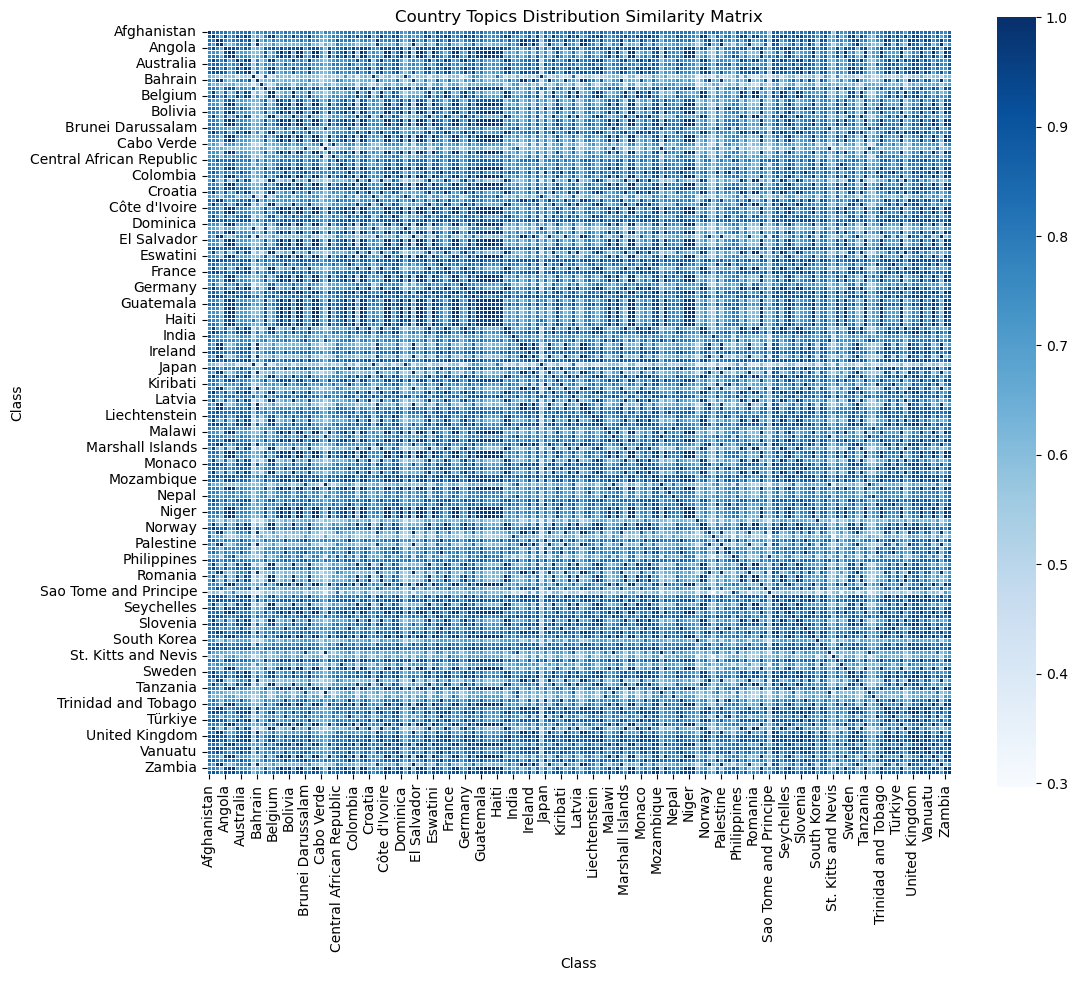

In [87]:
plt.figure(figsize=(12, 10))
sns.heatmap(sim_df, 
            cmap="Blues", 
            annot=False,
            square=True, 
            linewidths=.5)

plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.title("Country Topics Distribution Similarity Matrix")
plt.show()

In [ ]:
# 6. Export Edge List
# First, clear the index and column names to avoid "Class" confict
sim_df.index.name = None
sim_df.columns.name = None

edges = sim_df.stack().reset_index()
edges.columns = ['Source', 'Target', 'Weight']

# Remove self-loops (A-A) and redundant pairs (keep A-B, remove B-A)
edge_table = edges[edges['Source'] < edges['Target']].sort_values(by='Weight', ascending=False)
edge_table.to_csv("semantic_network_edges.csv", index=False)